In [11]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [1]:
import tempfile
import pickle
import sys
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pprint import pprint

from scipy.special import logit, softmax
from scipy.stats import wilcoxon, combine_pvalues

from one.api import ONE

import os
from os.path import join
from glob import glob

In [28]:
def get_results_dir(eid, decoding_dir, one=None):
    if one is None:
        # one = ONE()
        raise ValueError("`one` cannot be None")
    subject = one.get_details(eid)["subject"]
    return join(decoding_dir, subject, eid)


def get_summary_file(eid, decoding_dir, one=None):
    if one is None:
        # one = ONE()
        raise ValueError("`one` cannot be None")
    subject = one.get_details(eid)["subject"]
    results_dir = get_results_dir(eid, decoding_dir, one=one)
    return join(results_dir, "decoding_summary.pqt")


def get_decoding_summary_df(eid, decoding_dir, one=None):
    if one is None:
        # one = ONE()
        raise ValueError("`one` cannot be None")
    results_dir = get_results_dir(eid, decoding_dir, one=one)
    decoding_summary_files = glob(join(results_dir, "*_decoding_summary.pqt"))
    if not len(decoding_summary_files):
        raise Exception("No decoding summary files")

    _df = pd.concat(
        [
            (
                pd.read_parquet(f)
                # [PATCH] adding N_units -- due to bug in fit_data, N_units = 1
                .assign(N_units=lambda x: x["weights"].values[0].shape[-1])
            )
            for f in decoding_summary_files
        ],
        axis=0,
        ignore_index=True,
    )
    return _df


def get_all_results(eids, decoding_dir, exclude=None, one=None):
    if one is None:
        # one = ONE()
        raise ValueError("`one` cannot be None")
    if exclude is None:
        exclude = []
    _dfs = [
        (
            get_decoding_summary_df(eid, decoding_dir, one=one)
            .drop(["weights", "intercept"], axis=1)
            .assign(directory=get_results_dir(eid, decoding_dir, one=one))
        )
        for eid in eids
        if eid not in exclude
    ]
    return pd.concat(_dfs, axis=0, ignore_index=True)

In [4]:
decoding_dir = "../data/ephys/"

In [7]:
from brainwidemap.bwm_loading import bwm_query, bwm_units, load_trials_and_mask, merge_probes
from manifold.decoding.functions.utils import check_config_decoding

In [9]:
one = ONE()
config = check_config_decoding()
units_df = bwm_units(one)
MY_REGIONS = config["stim_prior_regions"]
relevant_pids = units_df[units_df["Beryl"].isin(MY_REGIONS)]["pid"].unique()

bwm_df = bwm_query(one)
subset_df = bwm_df[bwm_df["pid"].isin(relevant_pids)]
list_of_eids = subset_df["eid"].unique()

Loading bwm_query results from fixtures/2023_12_bwm_release.csv
d16d0b38d392b18c0ce8b615ec89d60d7c901df2eeb3432986b62130af28ef01
Loading bwm_query results from fixtures/2023_12_bwm_release.csv


In [17]:
a = get_results_dir(decoding_dir=decoding_dir, eid=list_of_eids[0], one=one)

In [26]:
_df = get_decoding_summary_df(list_of_eids[0], decoding_dir, one=one)

In [31]:
# check all errors
def check_results(eids, decoding_dir, one=None):
    if one is None:
        # one = ONE()
        raise ValueError("`one` cannot be None")
    failed_sessions = []
    error_messages = []
    for i, eid in enumerate(eids):

        try:
            _df = get_decoding_summary_df(eid, decoding_dir, one=one)

        except Exception as e:
            subject = one.get_details(eid)["subject"]
            print(f"{i+1:<5} {eid}    {subject:<15} {e}")
            failed_sessions.append(eid)
            error_messages.append(f"{type(e).__name__}: {e.args}")
            continue

    return failed_sessions, error_messages

In [32]:
failed_sessions, error_messages = check_results(list_of_eids, decoding_dir, one)

22    5bcafa14-71cb-42fa-8265-ce5cda1b89e0    NYU-45          No decoding summary files
157   d71e565d-4ddb-42df-849e-f99cfdeced52    PL017           No decoding summary files
159   283ecb4c-e529-409c-9f0a-8ea5191dcf50    PL030           No decoding summary files
288   a7763417-e0d6-4f2a-aa55-e382fd9b5fb8    ibl_witten_20   No decoding summary files


In [33]:
df = get_all_results(list_of_eids, decoding_dir, exclude=failed_sessions, one=one)

In [38]:
def get_weights(eid, decoding_dir, one=None):
    if one is None:
        # one = ONE()
        raise ValueError("`one` cannot be None")
    _df = get_decoding_summary_df(eid, decoding_dir, one=one)
    weights_dict = {"real": {}, "pseudo": {}}
    for region, region_df in _df.groupby("region"):
        mask = region_df.pseudo_id == -1
        weights_real = np.stack(region_df[mask].weights.to_list())
        intercept_real = np.stack(region_df[mask].intercept.to_list()).reshape(-1, 1)
        weights_dict["real"][region] = {
            "weights": weights_real,
            "intercept": intercept_real,
        }

        mask = region_df.pseudo_id != -1
        if mask.sum():
            weights_pseudo = np.stack(region_df[mask].weights.to_list())
            intercept_pseudo = np.stack(region_df[mask].intercept.to_list()).reshape(-1, 1)
            weights_dict["pseudo"][region] = {
                "weights": weights_pseudo,
                "intercept": intercept_pseudo,
            }

    return weights_dict


def get_stats_by_region(df, decoding_dir, mask, one=None):
    """
    Aggregating across eids, pseudo_ids and run_ids
    """
    _dfs = []
    for region, reg_df in df[mask].groupby("region"):

        weights_reg = []
        for eid, x in reg_df.groupby("eid"):
            _weights = get_weights(eid, decoding_dir, one=one)
            weights_reg += list(_weights["real"][region]["weights"])

        _weights = np.concatenate(weights_reg)

        try:
            pvalue = wilcoxon(_weights).pvalue
        except ValueError as e:
            print(f'{region}, {eid}: {type(e).__name__}: {";".join([*e.args])}')
            pvalue = np.nan
        _weights_mean = np.mean(_weights)
        _weights_median = np.median(_weights)
        _weights_std = np.std(_weights)
        _neg_frac = len(np.where(_weights < 0)[0]) / len(_weights)

        names = {
            "region": region,
            "n_sessions": reg_df["eid"].count(),  # number of sessions where region appears
            # stats of scores
            "Rsquared_mean": reg_df["R2_test"].mean(),
            "Rsquared_median": reg_df["R2_test"].median(),
            "Rsquared_std": reg_df["R2_test"].std(),
            "weights_mean": _weights_mean,
            "weights_median": _weights_median,
            "weights_std": _weights_std,
            "CDF-0": _neg_frac,
            "p-value": min(_neg_frac, 1 - _neg_frac),
            "p-wilcoxon": pvalue,
        }

        _dfs.append(pd.Series(names, index=list(names.keys())))

    return pd.concat(_dfs, axis=1).T

In [39]:
mask = df["pseudo_id"] == -1  # & (df['R2_test'] > 0)

In [40]:
regions_df = get_stats_by_region(df, decoding_dir, mask, one=one).set_index("region")

In [42]:
regions_df = regions_df[regions_df.n_sessions > 1]

In [43]:
from iblatlas.plots import plot_swanson_vector
import matplotlib as mpl

/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/iblatlas/regions.py:663: RuntimeWarning: All-NaN slice encountered
  all_values = np.nanmedian(v, axis=0)


<Axes: title={'center': '$R^2$'}>

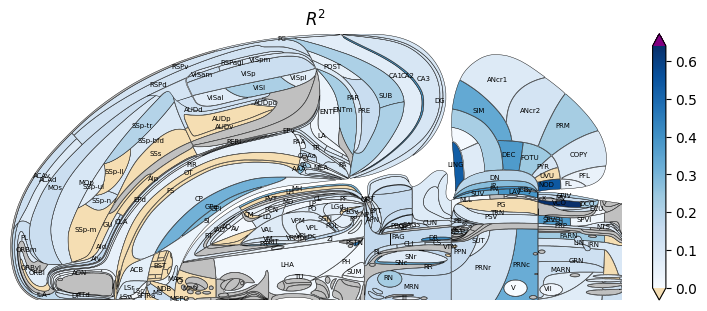

In [47]:
ig, ax = plt.subplots(figsize=(7, 3), layout="constrained")

values = regions_df["Rsquared_median"].values
acronyms = regions_df.index.to_numpy()
cmap = mpl.cm.Blues
cmap.set_extremes(under="wheat", over="purple")
ax.set_axis_off()
ax.set_title(r"$R^2$")
plot_swanson_vector(
    acronyms,
    values,
    ax=ax,
    cmap=cmap,
    annotate=True,
    annotate_list=acronyms,
    fontsize=5,
    empty_color="silver",
    vmin=0,
    vmax=np.max(values),
    show_cbar=True,
    extend="both",
)

In [56]:
from statsmodels.stats.multitest import multipletests

In [57]:
def test_region_significance(df, alpha=0.05):
    grouped = df.groupby(["region", "pseudo_id"])["R2_test"].mean().reset_index()

    real_df = grouped[grouped["pseudo_id"] == -1].set_index("region")["R2_test"]
    pseudo_df = grouped[grouped["pseudo_id"] != -1]

    results = []

    for region, real_r2 in real_df.items():
        null_r2s = pseudo_df[pseudo_df["region"] == region]["R2_test"].values
        n_nulls = len(null_r2s)

        if n_nulls == 0:
            continue

        n_greater_or_equal = np.sum(null_r2s >= real_r2)

        p_val_raw = (n_greater_or_equal + 1) / (n_nulls + 1)
        n_sessions = len(df[(df["region"] == region) & (df["pseudo_id"] == -1)]["eid"].unique())

        results.append(
            {
                "region": region,
                "n_sessions": n_sessions,
                "real_R2_mean": real_r2,
                "p_value_raw": p_val_raw,
            }
        )

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values("p_value_raw").reset_index(drop=True)
    reject, pvals_corrected, _, _ = multipletests(
        results_df["p_value_raw"], alpha=alpha, method="fdr_bh"
    )

    results_df["p_value_fdr"] = pvals_corrected
    results_df["is_significant"] = reject

    return results_df

In [61]:
significance_df = test_region_significance(df)

In [74]:
pseduosessions = np.arange(0, 100)
pseduosessions_argument = np.concat([[-1], pseduosessions])

In [76]:
pseduosessions_argument

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
       33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49,
       50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66,
       67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83,
       84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])